In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

In [2]:
# Load dataset
df = pd.read_csv("Dataset .csv")

# Display first 5 rows
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
# Dataset shape
print("Shape:", df.shape)

# Column names
print("\nColumns:\n")
print(df.columns)

Shape: (9551, 21)

Columns:

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')


In [4]:
# Select useful columns

data = df[[
    'Restaurant Name',
    'City',
    'Cuisines',
    'Average Cost for two',
    'Price range',
    'Votes',
    'Aggregate rating'
]]

data.head()

,Restaurant Name,City,Cuisines,Average Cost for two,Price range,Votes,Aggregate rating
0,Le Petit Souffle,Makati City,"French, Japanese, Desserts",1100,3,314,4.8
1,Izakaya Kikufuji,Makati City,Japanese,1200,3,591,4.5
2,Heat - Edsa Shangri-La,Mandaluyong City,"Seafood, Asian, Filipino, Indian",4000,4,270,4.4
3,Ooma,Mandaluyong City,"Japanese, Sushi",1500,4,365,4.9
4,Sambo Kojin,Mandaluyong City,"Japanese, Korean",1500,4,229,4.8


In [5]:
# Check missing values
data.isnull().sum()

,0
Restaurant Name,0
City,0
Cuisines,9
Average Cost for two,0
Price range,0
Votes,0
Aggregate rating,0


In [6]:
# Fill missing categorical values

data['Cuisines'] = data['Cuisines'].fillna('Unknown')
data['City'] = data['City'].fillna('Unknown')

# Check again
data.isnull().sum()

/tmp/ipykernel_5479/1162277834.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cuisines'] = data['Cuisines'].fillna('Unknown')
/tmp/ipykernel_5479/1162277834.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['City'] = data['City'].fillna('Unknown')


,0
Restaurant Name,0
City,0
Cuisines,0
Average Cost for two,0
Price range,0
Votes,0
Aggregate rating,0


In [7]:
# Create label encoder
encoder = LabelEncoder()

# Encode categorical columns
data['Restaurant Name'] = encoder.fit_transform(data['Restaurant Name'])

data['City'] = encoder.fit_transform(data['City'])

data['Cuisines'] = encoder.fit_transform(data['Cuisines'])

data.head()

/tmp/ipykernel_5479/501042064.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Restaurant Name'] = encoder.fit_transform(data['Restaurant Name'])
/tmp/ipykernel_5479/501042064.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['City'] = encoder.fit_transform(data['City'])
/tmp/ipykernel_5479/501042064.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: h

,Restaurant Name,City,Cuisines,Average Cost for two,Price range,Votes,Aggregate rating
0,3748,73,920,1100,3,314,4.8
1,3172,73,1111,1200,3,591,4.5
2,2896,75,1671,4000,4,270,4.4
3,4707,75,1126,1500,4,365,4.9
4,5523,75,1122,1500,4,229,4.8


In [8]:
# Features
X = data.drop('Aggregate rating', axis=1)

# Target
y = data['Aggregate rating']

In [9]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7640, 6)
Testing data: (1911, 6)


In [10]:
# Create model
model = RandomForestRegressor()

# Train model
model.fit(X_train, y_train)

RandomForestRegressor()

In [11]:
# Predict ratings
y_pred = model.predict(X_test)

# Display predictions
print(y_pred[:10])

[2.925 3.052 3.192 3.664 3.    0.    3.112 0.    2.937 3.565]


In [12]:
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# R2 Score
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.098458802823945
R2 Score: 0.9567424920146036


In [13]:
# Feature importance

importance = model.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

                Feature  Importance
5                 Votes    0.951719
2              Cuisines    0.012785
0       Restaurant Name    0.011586
1                  City    0.010687
3  Average Cost for two    0.010144
4           Price range    0.003078


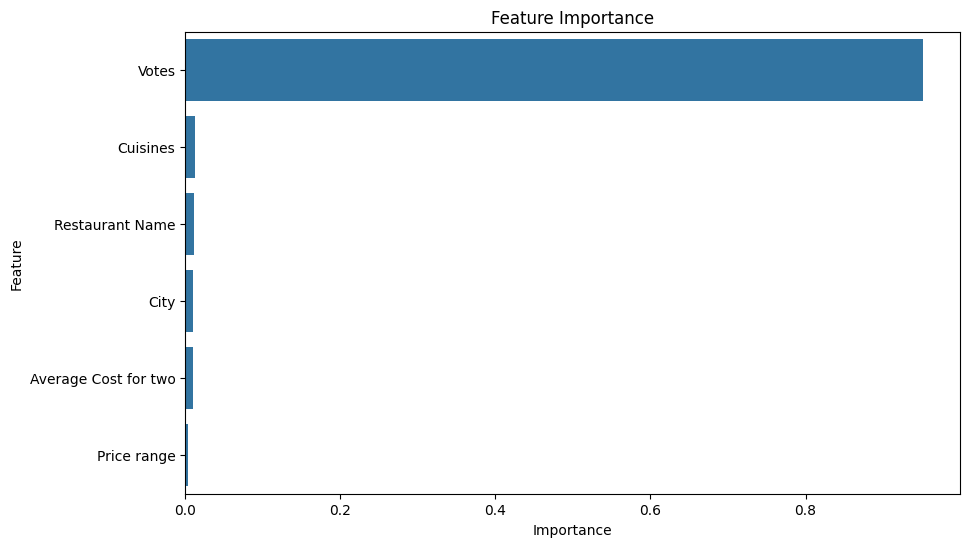

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance")
plt.show()

# Insights

1. Votes and price range strongly influence restaurant ratings.

2. Certain cuisines tend to receive higher ratings.

3. Restaurant location also impacts ratings.

4. Random Forest Regressor performed effectively for prediction.

5. Feature importance analysis helped identify the most influential factors.

# Conclusion

This project developed a machine learning model to predict restaurant ratings using restaurant-related features.

The workflow included:
- Data preprocessing
- Missing value handling
- Encoding categorical variables
- Model training
- Performance evaluation
- Feature importance analysis

The Random Forest Regressor achieved good predictive performance and identified important factors affecting restaurant ratings.